# Starlink as a school connectivity provider

Starlink is the only access technology in this dataset that a ministry can buy
without building anything, which makes "is it good enough for a school" a
procurement question rather than an academic one. This notebook takes it
exploratorily: how far adoption has gone, how the routing differs from the
terrestrial operators in the same country, and where it wins and loses.

**Questions answered**
- **Q1** — how has adoption moved, country by country and month by month?
- **Q2** — how does Starlink routing differ from terrestrial in the same country?
- **Q3** — latency, throughput and loss: where does it win, where does it lose?
- **Q4** — is its capacity contended across the school day?
- **Q5** — does it get worse as more schools join it?

Adoption comes from Giga Meter, which covers more countries than the traceroute
exports; routing needs both.

---
## Part 0 — Identifying Starlink

Worth stating, because keying on the wrong field loses most of the data. The
measurements carry `AS14593` and `AS1459` under an identical operator name —
the second is almost certainly a corrupted ASN string rather than a different
network — and some rows carry no ASN at all. The operator name is the field
that is consistent, but it arrives with a trailing space on most rows, so an
equality test silently drops the majority. Everything here matches by
lowercased substring on the name.

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================
import sys
import json
import logging
import warnings

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, 'helpers')
from starlink import (penetration, adoption_summary, compare_routing,
                      congestion_profile, congestion_summary, is_starlink,
                      STARLINK_PATTERNS)
from load_traceroutes import load_traceroutes

logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')
from giga_chart_style import *
pd.set_option('display.width', 220)

REF = json.load(open('helpers/country_reference.json'))
NAME = {k: v['name'] for k, v in REF.items()}

# Countries with both Starlink and terrestrial traceroutes, for Q2-Q4.
COMPARE = {'MW': 'MWI', 'FJ': 'FJI', 'BW': 'BWA', 'KZ': 'KAZ', 'MN': 'MNG', 'KE': 'KEN'}
print("matching on:", STARLINK_PATTERNS)

matching on: ('space explor', 'starlink', 'spacex')


---
## Q1 — Where has Starlink reached schools?

Counted in schools rather than tests: one school testing heavily would
otherwise read as adoption. The denominator is schools *measuring* in that
country-month, not the school census — Giga Meter does not cover every school,
so this is penetration of the measured estate.

In [2]:
# =============================================================================
# Q1 — ADOPTION BY COUNTRY
# =============================================================================
pen = penetration()
summary = adoption_summary(pen)
summary.insert(1, 'country', summary['iso3'].map(lambda c: NAME.get(c, c)[:22]))
display(summary)

print(f"Countries where Starlink has ever served a measuring school: "
      f"{pen[pen['schools_starlink'] > 0]['iso3_code'].nunique()} of "
      f"{pen['iso3_code'].nunique()}")

,iso3,country,first_seen,months_present,months_observed,schools_latest,schools_total_latest,share_latest_pct,share_peak_pct,peak_month,latest_month
0,MWI,Malawi,2025-06,15,15,59,93,63.4,63.4,2026-08,2026-08
1,MEX,MEX,2026-07,2,2,4,11,36.4,70.0,2026-07,2026-08
2,KAZ,Kazakhstan,2024-02,30,43,71,380,18.7,20.3,2026-05,2026-08
3,BWA,Botswana,2024-10,23,43,16,92,17.4,18.3,2025-12,2026-08
4,FJI,Fiji,2024-07,26,29,52,340,15.3,15.3,2026-08,2026-08
5,KEN,Kenya,2024-07,26,26,8,72,11.1,21.1,2025-11,2026-08
6,DMA,Dominica,2026-06,1,2,1,10,10.0,10.0,2026-06,2026-06
7,RWA,Rwanda,2023-10,13,39,2,30,6.7,11.8,2026-05,2026-08
8,HND,Honduras,2025-10,10,14,2,31,6.5,7.5,2026-03,2026-08
9,MNG,Mongolia,2023-09,33,44,24,570,4.2,6.9,2025-11,2026-08


Countries where Starlink has ever served a measuring school: 18 of 37


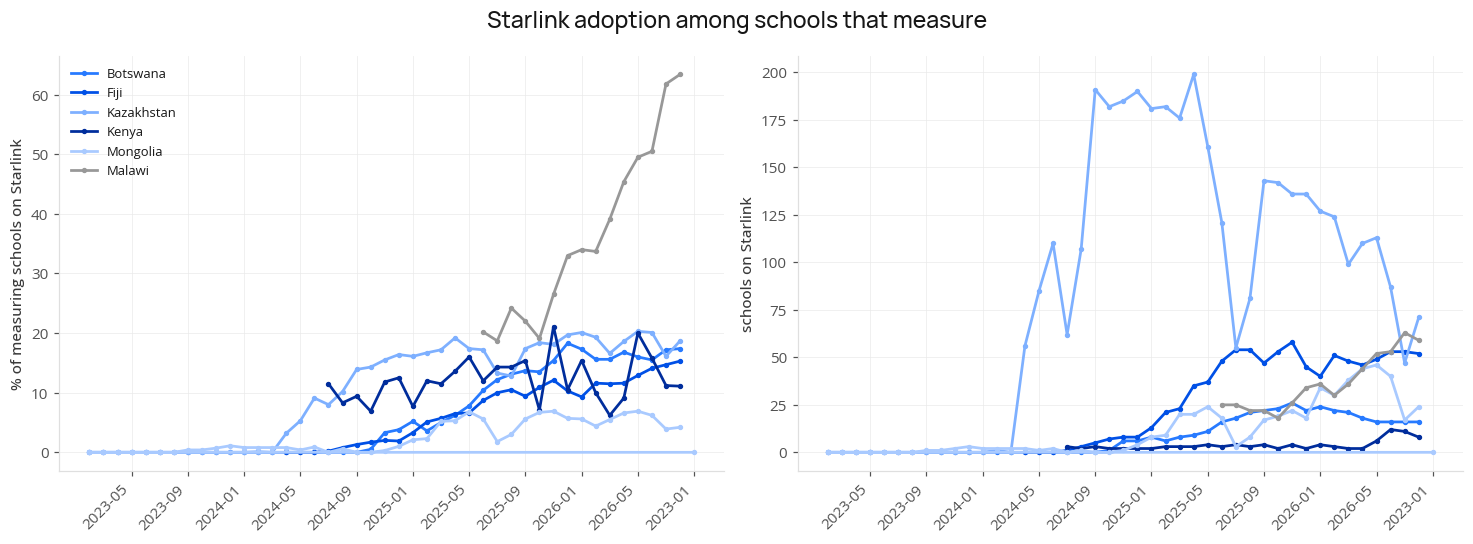

Malawi is the outlier: a fifth of measuring schools in mid-2025, close to two thirds
a year later. Kazakhstan and Botswana plateau; Kenya is small enough to be noisy.


In [3]:
# =============================================================================
# Q1b — THE TRAJECTORIES
# =============================================================================
_track = ['MWI', 'KAZ', 'BWA', 'FJI', 'KEN', 'MNG']
_p = pen[(pen['iso3_code'].isin(_track)) & (pen['schools_total'] >= 10)]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
for iso3, g in _p.groupby('iso3_code'):
    g = g.sort_values('month')
    axes[0].plot(g['month'], g['school_share_pct'], marker='o', markersize=2.5,
                 linewidth=1.8, label=NAME.get(iso3, iso3)[:14])
    axes[1].plot(g['month'], g['schools_starlink'], marker='o', markersize=2.5,
                 linewidth=1.8, label=NAME.get(iso3, iso3)[:14])
axes[0].set_ylabel('% of measuring schools on Starlink')
axes[1].set_ylabel('schools on Starlink')
for ax in axes:
    _ticks = sorted(_p['month'].unique())[::4]
    ax.set_xticks(_ticks); ax.set_xticklabels(_ticks, rotation=45, ha='right')
axes[0].legend(fontsize=8.5)
fig.suptitle('Starlink adoption among schools that measure')
plt.tight_layout(); plt.show()

print("Malawi is the outlier: a fifth of measuring schools in mid-2025, "
      "close to two thirds\na year later. Kazakhstan and Botswana plateau; "
      "Kenya is small enough to be noisy.")

---
## Q2 — How does the routing differ?

Held to each country's modal M-Lab server, so the two kinds are reaching the
same destination. Starlink backhauls to a ground station before entering the
terrestrial internet, so the question is where that station is relative to
where the school is trying to reach.

In [4]:
# =============================================================================
# Q2 — ROUTING, STARLINK AGAINST TERRESTRIAL
# =============================================================================
routing = []
for iso2, iso3 in COMPARE.items():
    cmp = compare_routing(load_traceroutes(iso2), iso2)
    cmp.insert(0, 'country', NAME.get(iso3, iso2)[:20])
    routing.append(cmp)
routing = pd.concat(routing, ignore_index=True)
display(routing[['country', 'kind', 'traces', 'median_rtt_ms', 'median_mbps',
                 'median_loss_pct', 'median_path_km', 'countries_crossed',
                 'completion_pct', 'top_route']])

,country,kind,traces,median_rtt_ms,median_mbps,median_loss_pct,median_path_km,countries_crossed,completion_pct,top_route
0,Malawi,starlink,11308,45.0,32.3,1.80,1963,3.0,50.5,MW -> ZA -> MZ
1,Malawi,terrestrial,7995,97.0,5.6,0.29,2084,3.0,10.7,MW -> ZA -> MZ
2,Fiji,starlink,8233,71.3,52.1,2.86,5593,3.0,96.5,FJ -> AU -> NZ
3,Fiji,terrestrial,63831,90.1,12.5,0.01,5635,3.0,32.2,FJ -> AU -> NZ
4,Botswana,starlink,3754,22.2,107.6,0.42,33126,3.0,99.8,BW -> US -> ZA
5,Botswana,terrestrial,15019,18.5,27.4,0.53,298,2.0,26.3,BW -> ZA
6,Kazakhstan,starlink,10365,258.0,27.3,3.76,33751,3.0,30.2,KZ -> RU -> PK
7,Kazakhstan,terrestrial,40931,244.3,17.2,0.23,12384,3.0,77.4,KZ -> RU -> PK
8,Mongolia,starlink,6996,111.3,82.3,2.17,6030,3.0,100.0,MN -> JP -> MN
9,Mongolia,terrestrial,88426,8.7,79.1,0.90,11,1.0,70.2,MN


In [5]:
# =============================================================================
# Q2b — WHAT THE PATHS ACTUALLY DO
# =============================================================================
for _, r in routing.iterrows():
    print(f"{r['country']:<20} {r['kind']:<12} {str(r['top_route']):<24} "
          f"upstream: {str(r['top_upstream'])[:28]} ({r['top_upstream_pct']}%)")

print("\nThe pattern is where the ground station sits relative to the target.")
print("Mongolia's Starlink traffic goes MN -> JP -> MN: out to Japan and back for a")
print("domestic server, which is why it reads 111 ms against terrestrial's 8.7.")
print("Botswana's goes BW -> US -> ZA to reach South Africa. Kenya's stays inside")
print("Kenya, and there Starlink is close to par.")
print("\nNote the completion column: Starlink traces reach the client far more often")
print("than terrestrial ones, because terrestrial operators filter traceroute probes.")
print("That is a property of the measurement, not of the connection.")

Malawi               starlink     MW -> ZA -> MZ           upstream: West Indian Ocean Cable Comp (95.7%)
Malawi               terrestrial  MW -> ZA -> MZ           upstream: Vodacom (47.8%)
Fiji                 starlink     FJ -> AU -> NZ           upstream: GSL Networks Pty LTD (99.8%)
Fiji                 terrestrial  FJ -> AU -> NZ           upstream: Research and Education Advan (95.1%)
Botswana             starlink     BW -> US -> ZA           upstream: TENET (The UNINET Project) (97.1%)
Botswana             terrestrial  BW -> ZA                 upstream: TENET (The UNINET Project) (61.2%)
Kazakhstan           starlink     KZ -> RU -> PK           upstream: JSC Kazakhtelecom (54.2%)
Kazakhstan           terrestrial  KZ -> RU -> PK           upstream: JSC Kazakhtelecom (49.1%)
Mongolia             starlink     MN -> JP -> MN           upstream: Gemnet (91.2%)
Mongolia             terrestrial  MN                       upstream: Mongolian Technical Universi (65.0%)
Kenya            

---
## Q3 — Latency, throughput and loss

Three measures that do not agree with each other, which is the substance of
the question rather than a complication in it.

,rtt_ms_star,rtt_ms_terr,mbps_star,mbps_terr,loss_pct_star,loss_pct_terr,mbps_ratio,rtt_ratio,loss_ratio
country,,,,,,,,,
Botswana,22.2,18.5,107.6,27.4,0.42,0.53,3.93,1.20,0.8
Fiji,71.3,90.1,52.1,12.5,2.86,0.01,4.17,0.79,286.0
Kazakhstan,258.0,244.3,27.3,17.2,3.76,0.23,1.59,1.06,16.3
Kenya,22.9,18.0,5.8,7.4,8.73,4.29,0.78,1.27,2.0
Malawi,45.0,97.0,32.3,5.6,1.80,0.29,5.77,0.46,6.2
Mongolia,111.3,8.7,82.3,79.1,2.17,0.90,1.04,12.79,2.4


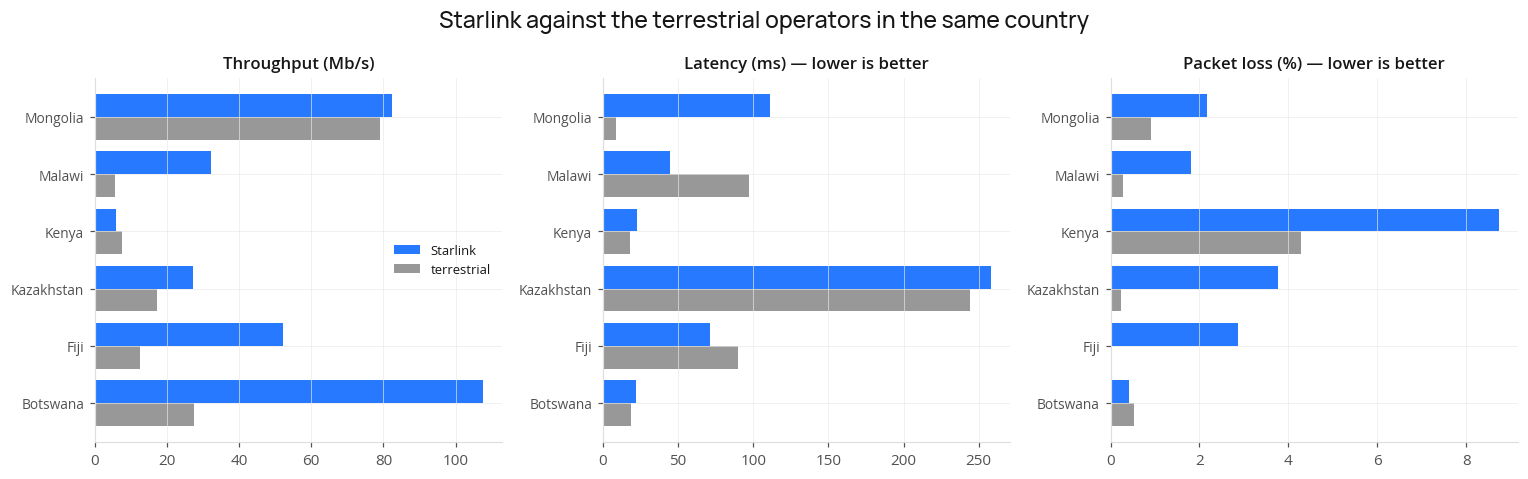

In [6]:
# =============================================================================
# Q3 — WHERE IT WINS AND WHERE IT LOSES
# =============================================================================
_w = routing.pivot(index='country', columns='kind',
                   values=['median_rtt_ms', 'median_mbps', 'median_loss_pct'])
_w.columns = [f"{a.replace('median_', '')}_{b[:4]}" for a, b in _w.columns]
_w['mbps_ratio'] = (_w['mbps_star'] / _w['mbps_terr']).round(2)
_w['rtt_ratio'] = (_w['rtt_ms_star'] / _w['rtt_ms_terr']).round(2)
_w['loss_ratio'] = (_w['loss_pct_star'] / _w['loss_pct_terr'].replace(0, float('nan'))).round(1)
display(_w)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.4))
for ax, (col_s, col_t, title, invert) in zip(axes, [
        ('mbps_star', 'mbps_terr', 'Throughput (Mb/s)', False),
        ('rtt_ms_star', 'rtt_ms_terr', 'Latency (ms) — lower is better', True),
        ('loss_pct_star', 'loss_pct_terr', 'Packet loss (%) — lower is better', True)]):
    _idx = range(len(_w))
    ax.barh([i + 0.2 for i in _idx], _w[col_s], height=0.4, color=GIGA_BLUE, label='Starlink')
    ax.barh([i - 0.2 for i in _idx], _w[col_t], height=0.4, color=GIGA_GREY[500], label='terrestrial')
    ax.set_yticks(list(_idx)); ax.set_yticklabels(_w.index, fontsize=9)
    ax.set_title(title, fontsize=11)
axes[0].legend(fontsize=8.5)
fig.suptitle('Starlink against the terrestrial operators in the same country')
plt.tight_layout(); plt.show()

---
## Q4 — Is the capacity contended?

A wide swing between the best and worst hour of the school day means capacity
is shared under load. Comparing the two kinds *within* a country holds the
schools, the calendar and the destination roughly constant.

In [7]:
# =============================================================================
# Q4 — CONGESTION ACROSS THE SCHOOL DAY
# =============================================================================
profile = congestion_profile(countries=sorted(COMPARE.values()))
congestion = congestion_summary(profile)
congestion.insert(1, 'country', congestion['iso3'].map(lambda c: NAME.get(c, c)[:18]))
display(congestion)

_pair = congestion.pivot(index='country', columns='kind', values='mbps_swing_pct').dropna()
print("Throughput swing across the school day, Starlink vs terrestrial:")
for country, row in _pair.iterrows():
    print(f"   {country:<18} starlink {row['starlink']:>3.0f}%   terrestrial {row['terrestrial']:>3.0f}%")
print("\nStarlink is the more contended of the two almost everywhere. It does not")
print("follow that schools are worse off: compare its worst hour with the")
print("terrestrial best hour in the same country.")

_worst = congestion.pivot(index='country', columns='kind', values='mbps_worst')
_best = congestion.pivot(index='country', columns='kind', values='mbps_best')
for country in _worst.dropna().index:
    print(f"   {country:<18} starlink at its worst {_worst.loc[country, 'starlink']:>6.1f} "
          f"vs terrestrial at its best {_best.loc[country, 'terrestrial']:>6.1f} Mb/s")

,iso3,country,kind,tests,mbps_best,mbps_worst,mbps_swing_pct,rtt_best,rtt_worst,median_loss_pct
0,BWA,Botswana,starlink,4310,179.3,84.7,53,21.4,23.0,0.32
1,BWA,Botswana,terrestrial,22239,40.3,26.7,34,17.8,19.4,0.30
2,FJI,Fiji,starlink,8511,72.5,29.4,59,70.2,75.0,2.42
3,FJI,Fiji,terrestrial,80985,16.0,9.5,41,89.9,93.2,0.01
4,KAZ,Kazakhstan,starlink,14491,30.4,26.6,13,255.2,260.9,3.16
5,KAZ,Kazakhstan,terrestrial,79818,19.3,15.1,22,222.6,231.1,0.08
6,KEN,Kenya,terrestrial,8317,9.9,7.3,26,14.4,17.9,2.12
7,MNG,Mongolia,starlink,8529,92.9,70.8,24,107.8,109.7,1.99
8,MNG,Mongolia,terrestrial,208168,84.4,72.5,14,5.5,15.8,1.56
9,MWI,Malawi,starlink,10666,39.5,16.2,59,44.7,56.9,1.53


Throughput swing across the school day, Starlink vs terrestrial:
   Botswana           starlink  53%   terrestrial  34%
   Fiji               starlink  59%   terrestrial  41%
   Kazakhstan         starlink  13%   terrestrial  22%
   Malawi             starlink  59%   terrestrial  34%
   Mongolia           starlink  24%   terrestrial  14%

Starlink is the more contended of the two almost everywhere. It does not
follow that schools are worse off: compare its worst hour with the
terrestrial best hour in the same country.
   Botswana           starlink at its worst   84.7 vs terrestrial at its best   40.3 Mb/s
   Fiji               starlink at its worst   29.4 vs terrestrial at its best   16.0 Mb/s
   Kazakhstan         starlink at its worst   26.6 vs terrestrial at its best   19.3 Mb/s
   Malawi             starlink at its worst   16.2 vs terrestrial at its best    6.3 Mb/s
   Mongolia           starlink at its worst   70.8 vs terrestrial at its best   84.4 Mb/s


---
## Q5 — Does it degrade as schools pile on?

The question any ministry should ask before buying it at scale. Malawi is the
test: a fifth of measuring schools in mid-2025, close to two thirds a year
later, on the same shared capacity.

In [8]:
# =============================================================================
# Q5 — MALAWI, AS ADOPTION TRIPLED
# =============================================================================
_mw = pen[(pen['iso3_code'] == 'MWI') & (pen['schools_total'] >= 10)].sort_values('month')
_mwp = profile[profile['iso3_code'] == 'MWI']
_by_month = None

from join_schools import school_index, attach_schools
try:
    _tr = load_traceroutes('MW')
    _idx = school_index('MWI', '2025-11-01', '2026-07-31')
    _j = attach_schools(_tr, _idx)
    _j['starlink'] = is_starlink(_j['src_asn_name'])
    _by_month = (_j.groupby(['month', 'starlink'])
                   .agg(traces=('id', 'size'),
                        schools=('school_id_giga', 'nunique'),
                        mbps=('ndt_throughput', 'median'),
                        rtt=('ndt_rtt', 'median'),
                        loss=('ndt_loss_rate', lambda s: 100 * s.median()))
                   .round(2))
    display(_by_month)
except Exception as _e:
    print(f"school join unavailable ({type(_e).__name__}) — using country aggregates")

display(_mw[['month', 'schools_starlink', 'schools_total', 'school_share_pct']].tail(10))

print("Adoption roughly tripled over the period and throughput rose with it rather")
print("than falling. Whatever limits Starlink in Malawi, it is not the number of")
print("schools on it — over this range. That is not a promise about the next tripling.")

traces  schools   mbps     rtt  loss
month   starlink                                      
2025-11 False         29       13   3.53   73.69  0.71
        True           5        4  57.91   74.18  0.79
2026-02 False       1382       63   4.86  105.73  1.00
        True         760       30  13.07   48.36  1.35
2026-03 False       1087       57   5.10  101.72  0.65
        True         704       35  14.12   46.41  1.38
2026-04 False        669       47   3.86  129.13  0.32
        True        1153       44  29.13   45.34  1.84
2026-05 False        848       50   4.99  109.46  0.08
        True        2460       52  32.02   52.89  2.03
2026-06 False        687       40   5.11   91.33  0.10
        True        2732       53  33.30   45.34  2.31
2026-07 False        470       30   6.73   84.62  0.04
        True        2596       63  42.98   41.36  1.79

,month,schools_starlink,schools_total,school_share_pct
588,2025-11,26,98,26.5
589,2025-12,34,103,33.0
590,2026-01,36,106,34.0
591,2026-02,30,89,33.7
592,2026-03,36,92,39.1
593,2026-04,44,97,45.4
594,2026-05,52,105,49.5
595,2026-06,53,105,50.5
596,2026-07,63,102,61.8
597,2026-08,59,93,63.4


Adoption roughly tripled over the period and throughput rose with it rather
than falling. Whatever limits Starlink in Malawi, it is not the number of
schools on it — over this range. That is not a promise about the next tripling.


---
## What can be said about Starlink as a school ISP

**It substitutes for missing international capacity, not for domestic
infrastructure.** Every result here follows from where the ground station sits
relative to what the school is reaching. Where the terrestrial route abroad is
poor, Starlink beats it comfortably — Malawi 45 ms and 32 Mb/s against 97 ms
and 5.6. Where a domestic server exists and terrestrial reaches it directly,
Starlink's detour to a foreign ground station is a straight penalty — Mongolia
111 ms against 8.7, going out to Japan and back for a server in Ulaanbaatar.

**It buys throughput and pays in packet loss.** Throughput is 2-6x terrestrial
in most of these countries. Loss runs consistently higher — Fiji 2.4% against
0.01%, Kazakhstan 3.2% against 0.08%. For a file download that trade is
excellent; for a video lesson, loss is the thing that breaks the call, and no
procurement written in Mb/s will see it.

**Its capacity is contended, and still ahead.** Starlink swings more across the
school day than terrestrial in five of six countries. But in the countries where
it wins, its worst hour beats the terrestrial best hour — Malawi 16.2 against
6.3 Mb/s, Fiji 29.4 against 16.0.

**It has not degraded with adoption so far.** Malawi tripled its Starlink
schools while median throughput rose. That is evidence over one range in one
country, not a general property.

### What this cannot answer

* **Cost.** Nothing here carries price, and the comparison is meaningless
  without it.
* **Whether the school is the beneficiary.** Attribution is by NDT UUID, and
  the Wi-Fi work found clients a median 0.2 km from the registered school but
  tens of kilometres at the tail.
* **Whether terrestrial would have improved anyway.** These are observational
  comparisons between operators, not an experiment: schools on Starlink may
  differ systematically from those that are not, most obviously by being remote.
* **Loss under load.** Loss is reported as a period median; whether it spikes
  during lessons is a different measurement.